In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)



In [3]:
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]





In [4]:
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    # convert value column to numercic (some lines may have non-numeric stuff)
    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

In [5]:
import pandas as pd
import numpy as np

# --- Endpoints: weekly vs monthly
START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df, value_col):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return df

def _median_ratio(a, b):
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return 1.0
    return np.median((x[mask] / y[mask]).values)

def stitch_three(w1, w2, w3, value_col, final_name=None):
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2 * s21

    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3 * s32

    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # Trim to weekly analysis window (Sundays)
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    if final_name is None:
        final_name = value_col
    out.columns = [final_name]
    out = out.reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series
indeed     = stitch_three(indeed_w1,     indeed_w2,     indeed_w3,     "indeed",     "indeed")
stepstone  = stitch_three(stepstone_w1,  stepstone_w2,  stepstone_w3,  "stepstone",  "stepstone")
Bewerbung  = stitch_three(Bewerbung_w1,  Bewerbung_w2,  Bewerbung_w3,  "bewerbung",  "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt", "arbeitsamt")
jobbörse   = stitch_three(jobbörse_w1,   jobbörse_w2,   jobbörse_w3,   "jobbörse",   "jobbörse")

# --- Sanity (weekly Sunday grid)
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobbörse), ("arbeitsamt", arbeitsamt), ("Bewerbung", Bewerbung)]:
    assert d["Date"].min() == START and d["Date"].max() == END_WEEK, f"{name} weekly range mismatch"
    assert (d["Date"].diff().dropna().dt.days == 7).all(), f"{name} not weekly by 7-day steps"

# --- Merge (weekly aligned)
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobbörse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(Bewerbung,  on="Date", how="inner"))

# Optional: save weekly
# df_week.to_csv("./new_data/google_weekly_stitched_merged.csv", index=False)

# --- If you want MONTHLY (to align with unemployment at month-end labels)
df_month = (df_week.set_index("Date")
                    .resample("M").mean()
                    .reset_index())
# Ensure last label is 2023-01-31
assert df_month["Date"].max() == END_MONTH, "Monthly last date not 2023-01-31"

# Optional: save monthly
# df_month.to_csv("./new_data/google_monthly_stitched_merged.csv", index=False)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33753/3039807760.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M").mean()


In [6]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# df_week: weekly merged Google Trends (columns like ['stepstone','indeed','jobbörse','arbeitsamt','bewerbung'])
# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print("✅ Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)


✅ Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörs

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33753/356134121.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33753/356134121.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_33753/356134121.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [7]:
data = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=',')
data_copy = data.copy()
data = data[(data["Date"]>= "2011-05-01") & (data["Date"] <= "2023-01-01")]
unemp = data 

In [8]:
unemp.columns = ["Date", "Unemp"]
unemp["Date"] = pd.to_datetime(unemp["Date"])
unemp = unemp.set_index("Date")
# align to month-end index
unemp.index = unemp.index.to_period("M").to_timestamp("M")
panel = biweekly.join(unemp, how="inner")
panel = panel.dropna()

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

# ----- settings (keep these identical across tests) -----
MAXLAG  = 6
AUTOLAG = 'AIC'   # or 'BIC'/'t-stat'

def eg_test(panel, y_name, x_name, trend='c'):
    """
    Engle–Granger cointegration test (statsmodels.coint) + manual residual-ADF
    using identical, aligned samples and the same lag policy.
    trend: 'n' (no const), 'c' (const), 'ct' (const+trend) for the long-run regression in coint().
    For the residual ADF, we use regression='n' (correct for residuals).
    """
    # 1) Align the sample ONCE (avoid mismatched dates)
    df = panel[[y_name, x_name]].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    y = df[y_name]
    x = df[x_name]

    # 2) Engle–Granger test via coint()  (uses MacKinnon EG critical values)
    stat_c, p_c, crit_c = coint(y, x, trend=trend, maxlag=MAXLAG, autolag=AUTOLAG)

    # 3) Manual residual ADF (correct spec for residuals: regression='n')
    lr = sm.OLS(y, sm.add_constant(x)).fit()
    resid = lr.resid

    # FIX #1: adfuller returns 6 values in newer statsmodels; slice the first 5
    adf_out = adfuller(resid, regression='n', maxlag=MAXLAG, autolag=AUTOLAG)
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit = adf_out[:5]

    # 4) Pretty print
    print(f"\n=== Engle–Granger test (y={y_name}, x={x_name}, trend='{trend}') ===")
    print(f"[coint()]     stat = {stat_c:.3f},  p = {p_c:.3f},  crit = {{'1%': {crit_c[0]:.3f}, '5%': {crit_c[1]:.3f}, '10%': {crit_c[2]:.3f}}}")
    print(f"[ADF residual] stat = {adf_stat:.3f}, p = {adf_p:.3f}, lags = {adf_lags}, n = {adf_nobs}")
    print(f"[ADF crit (standard DF)] {adf_crit}")  # note: these are standard DF crits, not EG crits
    return {
        "coint_stat": stat_c, "coint_p": p_c, "coint_crit": crit_c,
        "adf_stat": adf_stat, "adf_p": adf_p, "adf_lags": adf_lags, "adf_nobs": adf_nobs, "adf_crit": adf_crit
    }

# ----- example usage -----
# For your pair Unemp vs arbeitsamt_W34prev, with a constant in the long-run regression:
eg_test(panel, "Unemp", "stepstone_W12", trend='n')

# If you also want to check the trend case ('ct'):
# eg_test(panel, "Unemp", "arbeitsamt_W34prev", trend='ct')



=== Engle–Granger test (y=Unemp, x=stepstone_W12, trend='n') ===
[coint()]     stat = -3.391,  p = 0.009,  crit = {'1%': nan, '5%': nan, '10%': nan}
[ADF residual] stat = -2.814, p = 0.005, lags = 4, n = 135
[ADF crit (standard DF)] {'1%': -2.5825004938271605, '5%': -1.9431615757760505, '10%': -1.6149911999187114}


{'coint_stat': -3.390547677142971,
 'coint_p': 0.008672146067268165,
 'coint_crit': [nan, nan, nan],
 'adf_stat': -2.8137085020464303,
 'adf_p': 0.0047829423130469045,
 'adf_lags': 4,
 'adf_nobs': 135,
 'adf_crit': {'1%': -2.5825004938271605,
  '5%': -1.9431615757760505,
  '10%': -1.6149911999187114}}

# Cointegration test for zero mean

In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

def eg_case_nc(panel, y_name, x_name, maxlag=6, autolag='AIC'):
    df = panel[[y_name, x_name]].dropna().astype(float)
    y = df[y_name]
    x = df[x_name]

    # Step 1: OLS with NO constant, NO trend
    X = pd.DataFrame({'x': x})        # <-- no add_constant, no trend
    lr = sm.OLS(y, X).fit()
    resid = lr.resid

    # Engle–Granger test with matching deterministic spec
    eg_stat, eg_p, eg_crit = coint(y, x, trend='n', maxlag=maxlag, autolag=autolag)

    # Residual ADF is always regression='n'
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit = adfuller(resid, regression='n',
                                                             maxlag=maxlag, autolag=autolag)[:5]
    print(lr.summary())
    print(f"[coint nc] stat={eg_stat:.3f}, p={eg_p:.3f}, crit={tuple(round(c,3) for c in eg_crit)}")
    print(f"[ADF resid (n)] stat={adf_stat:.3f}, p={adf_p:.3f}, lags={adf_lags}, n={adf_nobs}")

    plt.figure(figsize=(8,3))
    plt.plot(resid.index, resid.values, label='Residuals (ε̂ₜ)', color='steelblue')
    plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Zero mean')
    plt.title(f"Residuals from cointegrating regression (Case 1: no constant)\n{y_name} ~ {x_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


                                 OLS Regression Results                                
Dep. Variable:                  Unemp   R-squared (uncentered):                   0.962
Model:                            OLS   Adj. R-squared (uncentered):              0.961
Method:                 Least Squares   F-statistic:                              3497.
Date:                Tue, 04 Nov 2025   Prob (F-statistic):                   2.06e-100
Time:                        11:54:06   Log-Likelihood:                         -222.04
No. Observations:                 140   AIC:                                      446.1
Df Residuals:                     139   BIC:                                      449.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

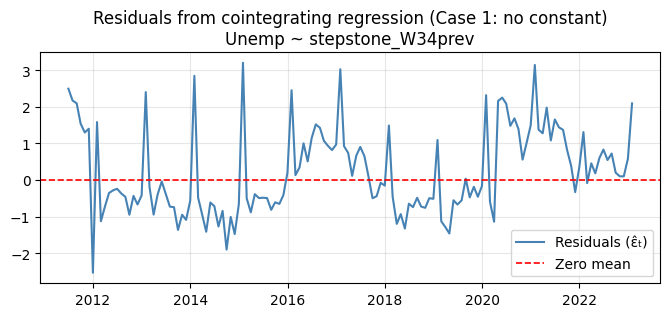

In [25]:
eg_case_nc(panel, "Unemp", "stepstone_W34prev")


In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = panel.copy()

# --- DIFFS (monthly)
df["dUnemp"] = df["Unemp"].diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)
df["dA34"] = df["stepstone_W34prev"].diff()
df["dA34_lag"] = df["dA34"].shift(1)
df["dA12"] = df["stepstone_W12"].diff()
df["dA12_lag"] = df["dA12"].shift(1)
df["month"] = df.index.month

# --- LONG-RUN RESIDUALS (CASE 'nc' = no constant)
# Use formula "0 +" to suppress the intercept in smf.ols
lr_nc_early = smf.ols("Unemp ~ 0 + stepstone_W34prev", data=df).fit()
df["EC_early_lag"] = lr_nc_early.resid.shift(1)

lr_nc_late  = smf.ols("Unemp ~ 0 + stepstone_W34prev + stepstone_W12", data=df).fit()
df["EC_late_lag"]  = lr_nc_late.resid.shift(1)

# --- DROP missing rows created by lags/diffs
used_cols = [
    "dUnemp","dUnemp_lag","dA34","dA34_lag","EC_early_lag",
    "dA12","dA12_lag","EC_late_lag","month"
]
used = df.dropna(subset=used_cols)

# --- ECMs (short run) WITH intercept (alpha0) + monthly dummies
# statsmodels includes an intercept by default in smf.ols
mod_early = smf.ols(
    "dUnemp ~ EC_early_lag + dUnemp_lag + dA34 + dA34_lag + C(month)",
    data=used
).fit(cov_type="HC1")  # robust SEs are sensible

mod_late  = smf.ols(
    "dUnemp ~ EC_late_lag  + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)",
    data=used
).fit(cov_type="HC1")

print("\n=== ECM (Early: A34 only, Case 'nc' long run) ===")
print(lr_nc_early.summary())
print(mod_early.summary())

print("\n=== ECM (Late: A34 + A12, Case 'nc' long run) ===")
print(lr_nc_late.summary())
print(mod_late.summary())



=== ECM (Early: A34 only, Case 'nc' long run) ===
                                 OLS Regression Results                                
Dep. Variable:                  Unemp   R-squared (uncentered):                   0.962
Model:                            OLS   Adj. R-squared (uncentered):              0.961
Method:                 Least Squares   F-statistic:                              3497.
Date:                Tue, 04 Nov 2025   Prob (F-statistic):                   2.06e-100
Time:                        12:07:14   Log-Likelihood:                         -222.04
No. Observations:                 140   AIC:                                      446.1
Df Residuals:                     139   BIC:                                      449.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                        coef    std err          t      P>|t|      [0

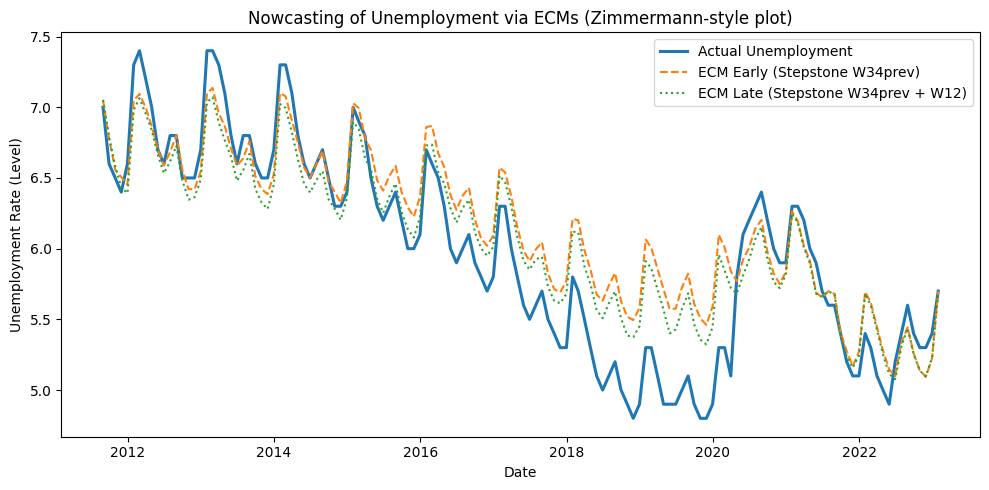


Speed of adjustment (EC term):
Early φ = -0.0109
Late  φ = -0.0066


In [27]:
# === Zimmermann-style ECM nowcasting plot (uses YOUR data in `panel`) ===
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

assert 'panel' in globals(), "`panel` DataFrame not found"
df = panel.copy()
assert isinstance(df.index, pd.DatetimeIndex), "panel.index must be a monthly DatetimeIndex"

# ---- 1) First differences & helpers ----
df["dUnemp"]     = df["Unemp"].diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)
df["dA34"]       = df["stepstone_W34prev"].diff()
df["dA34_lag"]   = df["dA34"].shift(1)
df["dA12"]       = df["stepstone_W12"].diff()
df["dA12_lag"]   = df["dA12"].shift(1)
df["month"]      = df.index.month

# ---- 2) Long-run residuals (EG Case 'nc': NO constant in Step 1) ----
# Early LR: Unemp ~ 0 + A34
lr_nc_early = smf.ols("Unemp ~ 0 + stepstone_W34prev", data=df).fit()
df["EC_early_lag"] = lr_nc_early.resid.shift(1)

# Late LR: Unemp ~ 0 + A34 + A12
lr_nc_late  = smf.ols("Unemp ~ 0 + stepstone_W34prev + stepstone_W12", data=df).fit()
df["EC_late_lag"]  = lr_nc_late.resid.shift(1)

# ---- 3) Estimation samples (drop NA introduced by diffs/lags) ----
used_early = df.dropna(subset=["dUnemp","dUnemp_lag","dA34","dA34_lag","EC_early_lag","month"]).copy()
used_late  = df.dropna(subset=["dUnemp","dUnemp_lag","dA34","dA34_lag","dA12","dA12_lag","EC_late_lag","month"]).copy()

# ---- 4) ECMs (short run): intercept + monthly dummies ----
mod_early = smf.ols(
    "dUnemp ~ EC_early_lag + dUnemp_lag + dA34 + dA34_lag + C(month)",
    data=used_early
).fit()

mod_late = smf.ols(
    "dUnemp ~ EC_late_lag + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)",
    data=used_late
).fit()

# ---- 5) Predict ΔUnemp in-sample and rebuild LEVEL paths ----
pred_d_early = pd.Series(mod_early.predict(used_early), index=used_early.index, name="dUnemp_hat_early")
pred_d_late  = pd.Series(mod_late.predict(used_late),  index=used_late.index,  name="dUnemp_hat_late")

def rebuild_level(level_series: pd.Series, d_hat: pd.Series) -> pd.Series:
    """Rebuild level path from predicted differences.
       Anchor = level at t-1 before first prediction, then cum-sum."""
    first_t = d_hat.index.min()
    # position of t-1 in the level index
    anchor_pos = level_series.index.get_loc(first_t) - 1
    if anchor_pos < 0:
        raise ValueError("Need at least one level observation before the first predicted difference.")
    anchor_level = level_series.iloc[anchor_pos]
    return (anchor_level + d_hat.cumsum()).rename("level_path")

path_early = rebuild_level(df["Unemp"], pred_d_early)
path_late  = rebuild_level(df["Unemp"], pred_d_late)

# Align actual to the common plotting window
plot_start = max(path_early.index.min(), path_late.index.min())
actual = df["Unemp"].loc[plot_start:]
path_early = path_early.loc[plot_start:]
path_late  = path_late.loc[plot_start:]

# ---- 6) Plot ----
plt.figure(figsize=(10,5))
plt.plot(actual.index, actual.values, label="Actual Unemployment", linewidth=2.2)
plt.plot(path_early.index, path_early.values, linestyle="--", label="ECM Early (Stepstone W34prev)")
plt.plot(path_late.index,  path_late.values,  linestyle=":",  label="ECM Late (Stepstone W34prev + W12)")
plt.title("Nowcasting of Unemployment via ECMs (Zimmermann-style plot)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (Level)")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: print key ECM coefficients (speed of adjustment φ)
print("\nSpeed of adjustment (EC term):")
print("Early φ =", round(mod_early.params.get("EC_early_lag", np.nan), 4))
print("Late  φ =", round(mod_late.params.get("EC_late_lag",  np.nan), 4))


OOS (ΔUnemp): n=38  RMSE=0.2180  MAE=0.1203


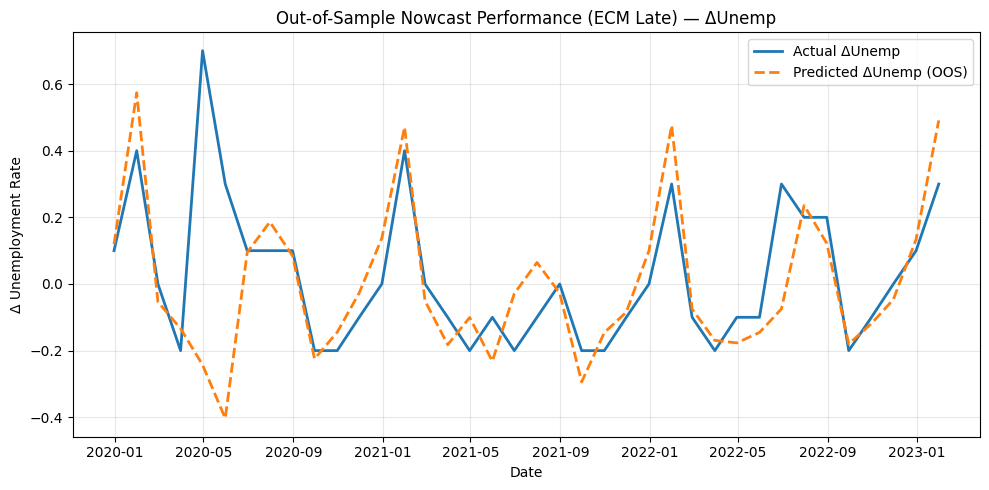

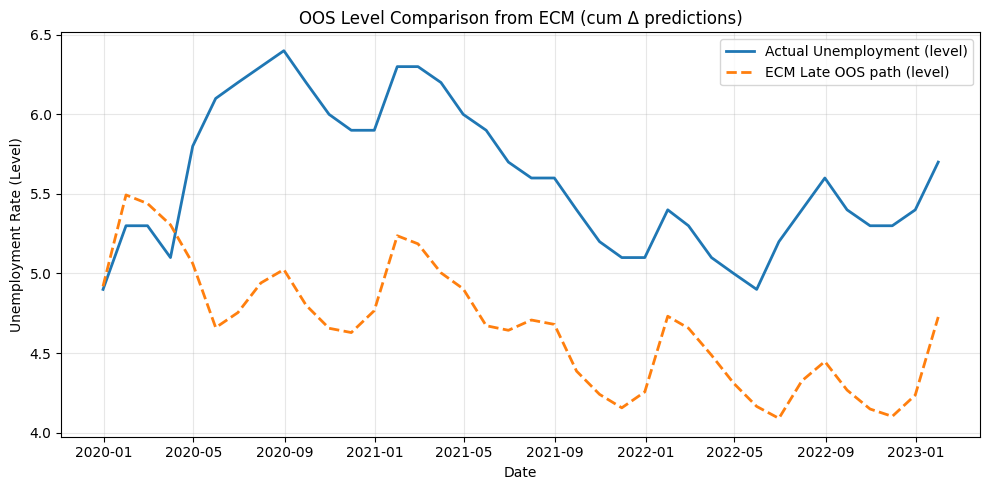

In [28]:
# OOS forecast test for ECM (Late spec) with expanding window and no leakage
import numpy as np, pandas as pd, statsmodels.formula.api as smf, matplotlib.pyplot as plt

# expects monthly `panel` with columns: Unemp, stepstone_W34prev, stepstone_W12
df0 = panel.copy()
assert isinstance(df0.index, pd.DatetimeIndex), "panel.index must be monthly"

def build_ecm_frame(df_slice):
    out = df_slice.copy()
    out["dUnemp"]     = out["Unemp"].diff()
    out["dUnemp_lag"] = out["dUnemp"].shift(1)
    out["dA34"]       = out["stepstone_W34prev"].diff()
    out["dA34_lag"]   = out["dA34"].shift(1)
    out["dA12"]       = out["stepstone_W12"].diff()
    out["dA12_lag"]   = out["dA12"].shift(1)
    out["month"]      = out.index.month
    lr = smf.ols("Unemp ~ 0 + stepstone_W34prev + stepstone_W12", data=out).fit()  # EG Case 'nc'
    out["EC_lag"] = lr.resid.shift(1)
    return out, lr

full, _ = build_ecm_frame(df0)

# choose OOS start (ensure valid after lags)
valid = full.dropna(subset=["dUnemp","dUnemp_lag","dA34","dA34_lag","dA12","dA12_lag","EC_lag"]).index
start_oos = max(100, 12)  # you can change 100
start_date = valid[start_oos]

preds, actuals, idx = [], [], []
for t in full.index[full.index.get_loc(start_date):]:
    tpos = full.index.get_loc(t)
    train_df = df0.iloc[:tpos]  # up to t-1
    train_ecm, _ = build_ecm_frame(train_df)
    train_used = train_ecm.dropna(subset=["dUnemp","dUnemp_lag","dA34","dA34_lag","dA12","dA12_lag","EC_lag"])
    if train_used.empty: 
        continue

    mod = smf.ols("dUnemp ~ EC_lag + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)", data=train_used).fit()

    # compute EC_lag for t using long-run estimated on TRAIN ONLY
    lr_train = smf.ols("Unemp ~ 0 + stepstone_W34prev + stepstone_W12", data=train_df).fit()
    resid_train = lr_train.resid
    test = full.iloc[[tpos]].copy()
    test.loc[:, "EC_lag"] = resid_train.iloc[-1]  # ε̂_{t-1}
    if test[["EC_lag","dUnemp_lag","dA34","dA34_lag","dA12","dA12_lag","month"]].isna().any().any():
        continue

    yhat = mod.predict(test).iloc[0]
    preds.append(yhat)
    actuals.append(full.loc[t, "dUnemp"])
    idx.append(t)

oos = pd.DataFrame({"actual":actuals, "pred":preds}, index=pd.Index(idx, name="Date"))
rmse = np.sqrt(np.mean((oos.actual - oos.pred)**2))
mae  = np.mean(np.abs(oos.actual - oos.pred))
print(f"OOS (ΔUnemp): n={len(oos)}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# Δ plot
plt.figure(figsize=(10,5))
plt.plot(oos.index, oos.actual, label="Actual ΔUnemp", linewidth=2)
plt.plot(oos.index, oos.pred,   label="Predicted ΔUnemp (OOS)", linestyle="--", linewidth=2)
plt.title("Out-of-Sample Nowcast Performance (ECM Late) — ΔUnemp")
plt.xlabel("Date"); plt.ylabel("Δ Unemployment Rate"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Level path (cum Δ) anchored at last in-sample level
anchor = df0["Unemp"].iloc[df0.index.get_loc(oos.index.min())-1]
lvl_path = anchor + oos.pred.cumsum()
actual_lvl = df0["Unemp"].loc[oos.index]

plt.figure(figsize=(10,5))
plt.plot(actual_lvl.index, actual_lvl.values, label="Actual Unemployment (level)", linewidth=2)
plt.plot(lvl_path.index,    lvl_path.values,  label="ECM Late OOS path (level)", linestyle="--", linewidth=2)
plt.title("OOS Level Comparison from ECM (cum Δ predictions)")
plt.xlabel("Date"); plt.ylabel("Unemployment Rate (Level)"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# Add a constant to the regression and a trend

In [10]:
import statsmodels.api as sm
import numpy as np

y = panel["Unemp"]
x = panel["stepstone_W34prev"]

# Add constant and linear trend
trend = np.arange(len(panel))
X = sm.add_constant(pd.DataFrame({'stepstone_W34prev': x, 'trend': trend}))

coint_reg_trend = sm.OLS(y, X).fit()
resid_trend = coint_reg_trend.resid

print(coint_reg_trend.summary())


                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     105.3
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           2.00e-28
Time:                        11:03:48   Log-Likelihood:                -86.841
No. Observations:                 140   AIC:                             179.7
Df Residuals:                     137   BIC:                             188.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.1395      0.28

# Auxiliary

In [65]:
import statsmodels.api as sm
import pandas as pd

# y = dependent variable, x = independent
y = panel["Unemp"]
X = panel["stepstone_W12"]

# add constant for intercept
X = sm.add_constant(X)

# estimate OLS
model = sm.OLS(y, X).fit()
print(model.summary())

# extract residuals (these are ε̂_t)
resid = model.resid


                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     74.68
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           1.24e-14
Time:                        20:16:32   Log-Likelihood:                -121.74
No. Observations:                 140   AIC:                             247.5
Df Residuals:                     138   BIC:                             253.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.9150      0.246     15.884

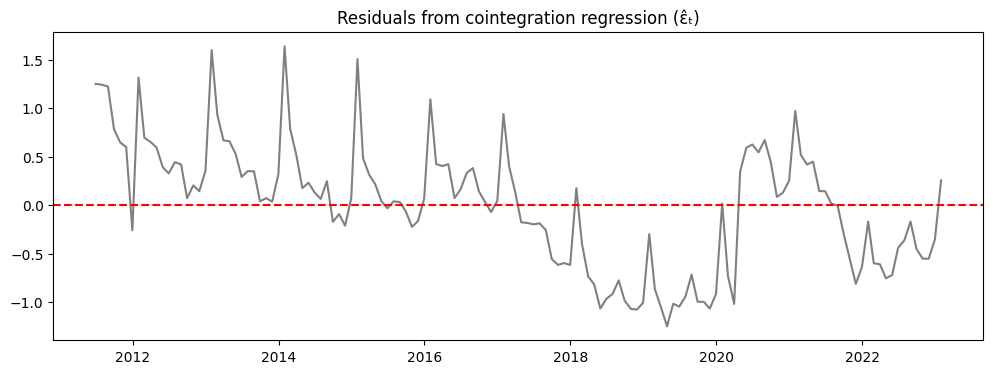

In [64]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(resid, color="gray")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals from cointegration regression (ε̂ₜ)")
plt.show()


In [31]:
from statsmodels.tsa.stattools import adfuller

resid = model.resid
adf_resid = adfuller(resid, regression='c',autolag='AIC')
print(f"ADF statistic = {adf_resid[0]:.3f},  p-value = {adf_resid[1]:.3f}")


ADF statistic = -3.154,  p-value = 0.023


In [58]:
import statsmodels.formula.api as smf

# Build variables once
df = panel.copy()
df["dUnemp"] = df["Unemp"].diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)
df["dA34"] = df["stepstone_W34prev"].diff()
df["dA34_lag"] = df["dA34"].shift(1)
df["dA12"] = df["stepstone_W12"].diff()
df["dA12_lag"] = df["dA12"].shift(1)
df["month"] = df.index.month
# EC from early long-run (Unemp ~ A34)
ec_early = smf.ols("Unemp ~ stepstone_W34prev", data=df).fit().resid
df["EC_early_lag"] = ec_early.shift(1)
# EC from late long-run (Unemp ~ A34 + A12)
ec_late = smf.ols("Unemp ~ stepstone_W34prev + stepstone_W12", data=df).fit().resid
df["EC_late_lag"] = ec_late.shift(1)

# Drop NA rows
used = df.dropna(subset=["dUnemp","dUnemp_lag","dA34","dA34_lag","EC_early_lag","dA12","dA12_lag","EC_late_lag","month"])

# Early ECM (W34 only)
mod_early = smf.ols("dUnemp ~ EC_early_lag + dUnemp_lag + dA34 + dA34_lag + C(month)", data=used).fit()
# Late ECM (W34 + W12)
mod_late  = smf.ols("dUnemp ~ EC_late_lag  + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)", data=used).fit()

print(mod_early.summary())
print(mod_late.summary())


                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     28.13
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           1.57e-32
Time:                        19:31:27   Log-Likelihood:                 115.07
No. Observations:                 138   AIC:                            -198.1
Df Residuals:                     122   BIC:                            -151.3
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4003      0.045      8.

In [59]:
import numpy as np
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))

y = used["dUnemp"]
rmse_early, mae_early = rmse(y, mod_early.fittedvalues), mae(y, mod_early.fittedvalues)
rmse_late,  mae_late  = rmse(y, mod_late.fittedvalues),  mae(y, mod_late.fittedvalues)
print("IN-SAMPLE   RMSE  Early/Late:", rmse_early, rmse_late)
print("IN-SAMPLE    MAE  Early/Late:", mae_early,  mae_late)
print("AIC Early/Late:", mod_early.aic, mod_late.aic)
print("BIC Early/Late:", mod_early.bic, mod_late.bic)


IN-SAMPLE   RMSE  Early/Late: 0.10510999047041493 0.10377330783137649
IN-SAMPLE    MAE  Early/Late: 0.06934532468567514 0.06912294854340925
AIC Early/Late: -198.13139870702918 -197.66379643591523
BIC Early/Late: -151.2953397445139 -144.97323010308554


In [60]:
# Joint test: H0: dA12 = 0 and dA12_lag = 0
print(mod_late.wald_test("dA12 = 0, dA12_lag = 0"))


<F test: F=array([[1.34265647]]), p=0.26504539444122854, df_denom=120, df_num=2>


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [61]:
import pandas as pd
yhat_E = mod_early.fittedvalues.rename("yhat_E")
yhat_L = mod_late.fittedvalues.rename("yhat_L")
tmp = pd.concat([used["dUnemp"], yhat_E, yhat_L], axis=1).dropna()

# Does Late encompass Early?
j_L = smf.ols("dUnemp ~ yhat_L + yhat_E", data=tmp).fit()
print(j_L.summary().tables[1])
# If coef on yhat_E is insignificant while yhat_L significant → Late encompasses Early.

# Does Early encompass Late?
j_E = smf.ols("dUnemp ~ yhat_E + yhat_L", data=tmp).fit()
print(j_E.summary().tables[1])
# If coef on yhat_L is insignificant while yhat_E significant → Early encompasses Late.


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.043e-06      0.009      0.000      1.000      -0.018       0.018
yhat_L         0.9447      0.504      1.874      0.063      -0.052       1.942
yhat_E         0.0557      0.506      0.110      0.912      -0.945       1.056
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.043e-06      0.009      0.000      1.000      -0.018       0.018
yhat_E         0.0557      0.506      0.110      0.912      -0.945       1.056
yhat_L         0.9447      0.504      1.874      0.063      -0.052       1.942


Reading it: if in the first regression yhat_L is significant but yhat_E isn’t, the Late model contains the useful variation from Early → Late is preferred (and vice versa).

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_28619/3548392015.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  used["pred_dUnemp_early"] = mod_early.fittedvalues
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_28619/3548392015.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  used["pred_dUnemp_late"]  = mod_late.fittedvalues
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_28619/3548392015.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

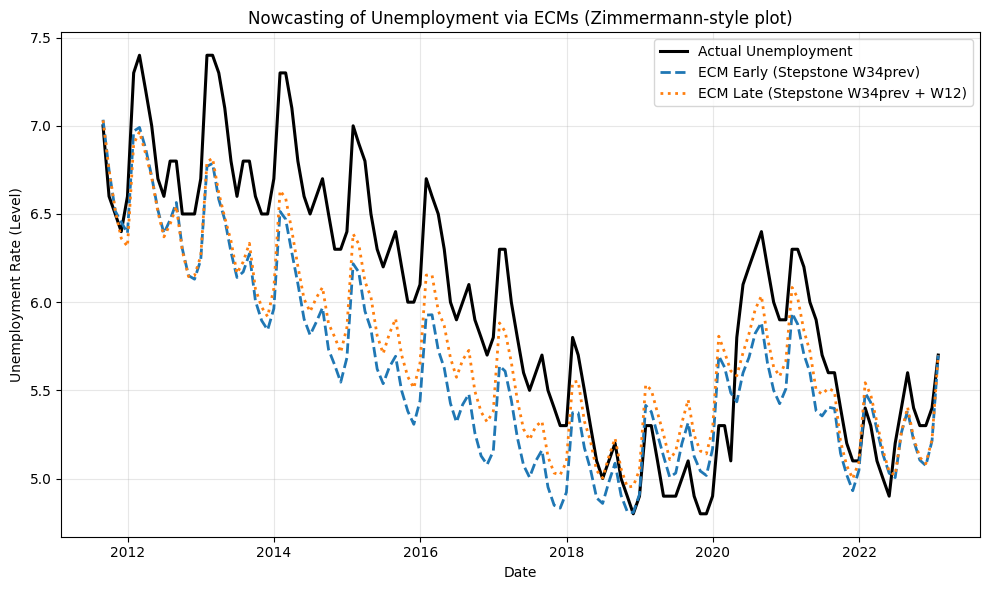

In [68]:
# forecast tets
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Prepare data
df = used.copy()
n_obs = len(df)
start_oos = 100  # for example: start forecasting after the first 100 months (~8 years)

preds = []
actuals = []

# Expanding window: re-estimate model each step and predict one-step ahead
for i in range(start_oos, n_obs - 1):  # leave last obs for prediction
    train = df.iloc[:i]        # data up to time t
    test  = df.iloc[i:i+1]     # next observation (t+1)
    
    # estimate model on training sample
    mod = smf.ols("dUnemp ~ EC_late_lag + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)", data=train).fit()
    
    # predict for next month
    yhat = mod.predict(test).iloc[0]
    preds.append(yhat)
    actuals.append(test["dUnemp"].values[0])

# turn into series
oos = pd.DataFrame({
    "actual": actuals,
    "pred": preds
}, index=df.index[start_oos+1:])  # align by date

# compute RMSE and MAE
rmse = np.sqrt(np.mean((oos["actual"] - oos["pred"])**2))
mae  = np.mean(np.abs(oos["actual"] - oos["pred"]))
print(f"OOS RMSE: {rmse:.4f}, OOS MAE: {mae:.4f}")


OOS RMSE: 0.2137, OOS MAE: 0.1178


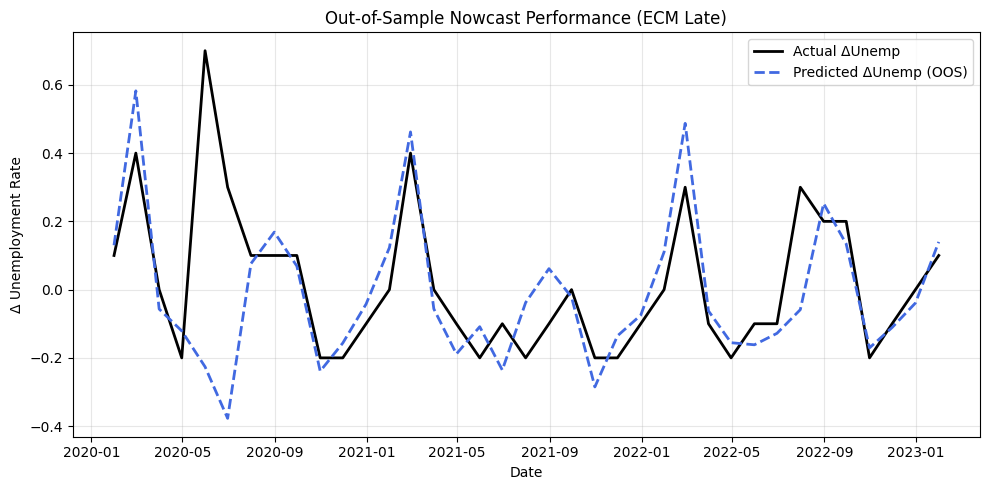

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(oos.index, oos["actual"], label="Actual ΔUnemp", color="black", linewidth=2)
plt.plot(oos.index, oos["pred"], label="Predicted ΔUnemp (OOS)", color="royalblue", linestyle="--", linewidth=2)
plt.title("Out-of-Sample Nowcast Performance (ECM Late)")
plt.xlabel("Date")
plt.ylabel("Δ Unemployment Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


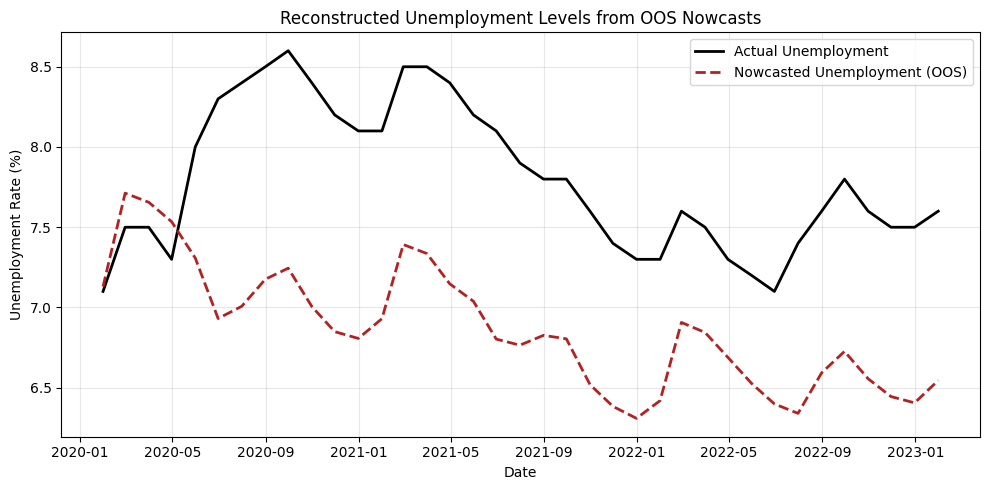

In [70]:
# reconstruct level paths
start_val = used["Unemp"].iloc[0]
oos["Unemp_actual"] = start_val + oos["actual"].cumsum()
oos["Unemp_pred"]   = start_val + oos["pred"].cumsum()

plt.figure(figsize=(10,5))
plt.plot(oos.index, oos["Unemp_actual"], label="Actual Unemployment", color="black", linewidth=2)
plt.plot(oos.index, oos["Unemp_pred"], label="Nowcasted Unemployment (OOS)", color="firebrick", linestyle="--", linewidth=2)
plt.title("Reconstructed Unemployment Levels from OOS Nowcasts")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [71]:
# correlation between predicted and actual
corr = oos["pred"].corr(oos["actual"])
bias = np.mean(oos["pred"] - oos["actual"])

print(f"OOS RMSE: {rmse:.3f}")
print(f"OOS MAE:  {mae:.3f}")
print(f"Correlation (pred vs actual): {corr:.3f}")
print(f"Mean bias: {bias:.3f}")


OOS RMSE: 0.214
OOS MAE:  0.118
Correlation (pred vs actual): 0.489
Mean bias: -0.029
